# 02 · Exploratory Data Analysis

**Battery RUL prediction — DLinear and NLinear vs tree-based models**

This notebook explores the capacity-fade trajectories of the 11 study cells (4 NASA PCoE, 7 CALCE CX2) to understand the data before any modelling. Each section ends with a design consequence.

| | |

|---|---|

| **Inputs** | `processed/cells/*.parquet`, `processed/cell_summary.csv` (from 01) |

| **Outputs** | `processed/regimes.csv`, `results/eda_*.csv`, `figures/02_*.png` |

Three properties matter most for the research questions:

* **Capacity regeneration** — sudden partial recoveries after rest. NLinear last-value anchoring and DLinear trend branch should respond differently (RQ1).

* **Level differences between cells** — cells start at different capacities, so a model trained on some cells must forecast others at levels it has not seen (RQ1 and RQ2).

* **How far the end-of-life region lies from the training data** — the premise of the RQ2 extrapolation test.

In [1]:
import os, sys
from pathlib import Path
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount("/content/drive")
    os.chdir("/content/battery-rul-linear")
    os.environ.setdefault("BATTERY_RUL_DATA", "/content/drive/MyDrive/battery_rul/data")
ROOT = Path.cwd().resolve()
if not (ROOT / "battery_rul").is_dir(): ROOT = ROOT.parent
os.environ.setdefault("BATTERY_RUL_ROOT", str(ROOT))
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from battery_rul import config
from battery_rul.dataset import cells_by_dataset, forecast_origins, load_cells, loco_folds, regeneration_regimes
from battery_rul.features import build_training_set, make_windows
from battery_rul.plotting import INK, INK_2, MUTED, degradation_curves, savefig, setup_style
from battery_rul.utils import markdown_table, record_run, save_table
pd.set_option("display.width", 160)
setup_style()
record_run("02_EDA")
summary = pd.read_csv(config.PROCESSED_DIR / "cell_summary.csv")
summary = summary[summary["group"].isin(config.STUDY_GROUPS)].reset_index(drop=True)
cells = load_cells()
REF = config.LABELS.primary_reference
print(f"{len(cells)} study cells:", cells_by_dataset(cells))

11 study cells: {'CALCE': ['CX2_16', 'CX2_33', 'CX2_34', 'CX2_35', 'CX2_36', 'CX2_37', 'CX2_38'], 'NASA': ['B0005', 'B0006', 'B0007', 'B0018']}


## 1. Dataset overview

In [3]:
overview = summary.groupby("dataset").agg(
    cells=("cell", "size"), cycles_min=("n_cycles", "min"), cycles_max=("n_cycles", "max"),
    initial_Ah_min=("initial_Ah", "min"), initial_Ah_max=("initial_Ah", "max"),
    eol_rated_min=("eol_rated", "min"), eol_rated_max=("eol_rated", "max"),
    eol_initial_min=("eol_initial", "min"), eol_initial_max=("eol_initial", "max"),
    reach_eol=("reaches_eol", "sum")).reset_index()
save_table(overview, "eda_overview")
print(markdown_table(overview, floatfmt=".3f"))
overview

| dataset   |   cells |   cycles_min |   cycles_max |   initial_Ah_min |   initial_Ah_max |   eol_rated_min |   eol_rated_max |   eol_initial_min |   eol_initial_max |   reach_eol |
|:----------|--------:|-------------:|-------------:|-----------------:|-----------------:|----------------:|----------------:|------------------:|------------------:|------------:|
| CALCE     |       7 |         1274 |         2007 |            1.269 |            1.364 |             621 |            1000 |               653 |              1117 |           7 |
| NASA      |       4 |          132 |          168 |            1.835 |            2.019 |              60 |              94 |                62 |               125 |           4 |


,dataset,cells,cycles_min,cycles_max,initial_Ah_min,initial_Ah_max,eol_rated_min,eol_rated_max,eol_initial_min,eol_initial_max,reach_eol
0,CALCE,7,1274,2007,1.2691,1.3636,621,1000,653,1117,7
1,NASA,4,132,168,1.8352,2.0191,60,94,62,125,4


## 2. Capacity fade

Raw capacity per cell (left) and the same trajectories as state of health (right). The spread on the left that collapses on the right is level difference, not a difference in degradation behaviour.

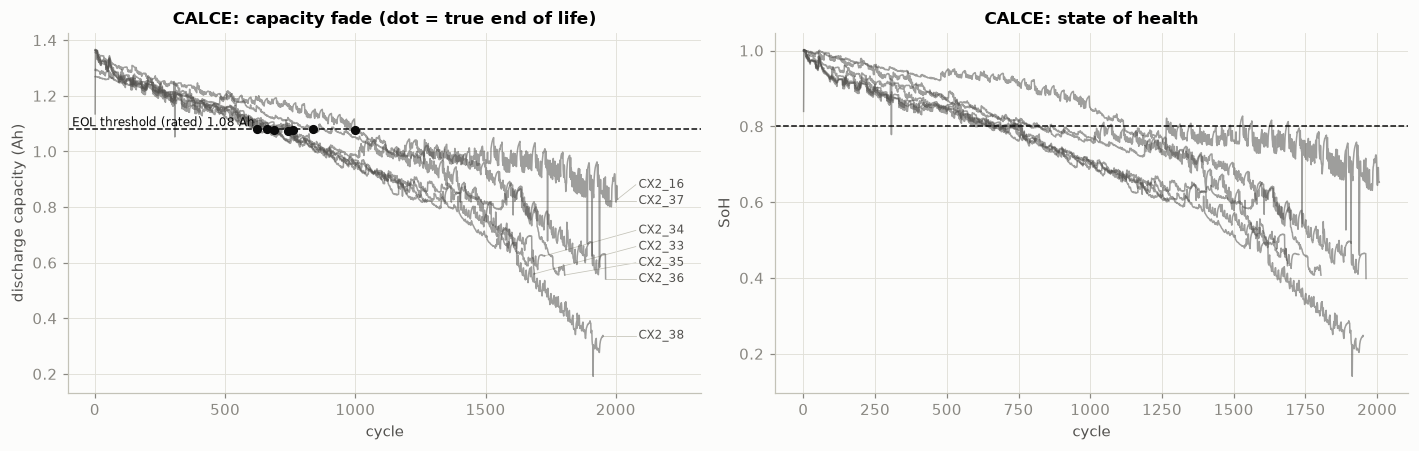

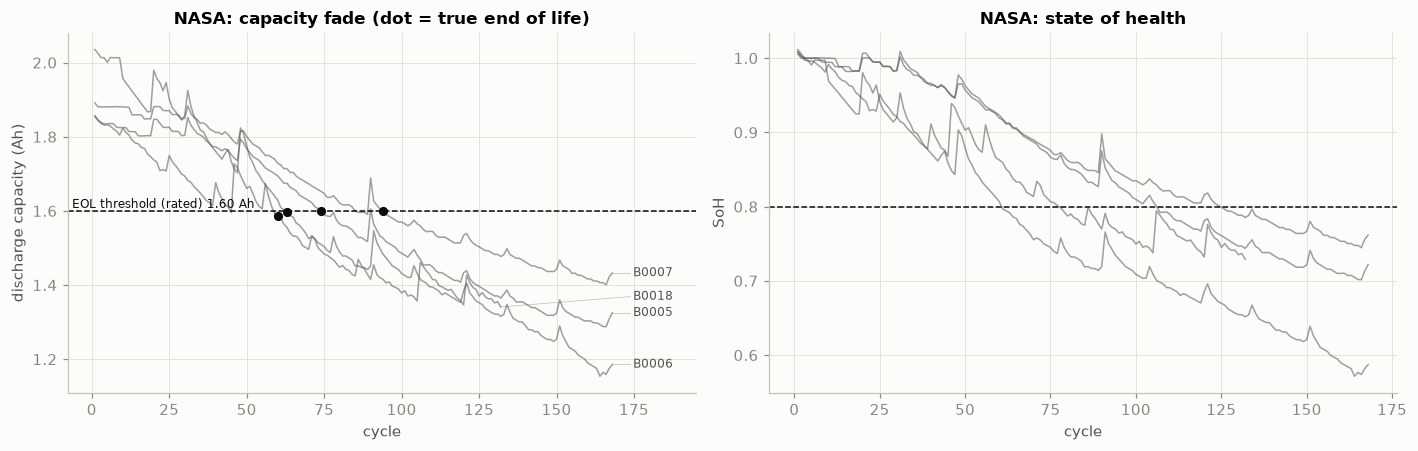

In [4]:
for ds in cells_by_dataset(cells):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    degradation_curves(cells, ds, REF, ax=axes[0])
    for c in (c for c in cells.values() if c.dataset == ds):
        soh = c.capacity / c.references["initial"]
        axes[1].plot(np.arange(1, c.n_cycles + 1), soh, color=INK_2, lw=1, alpha=0.55)
    axes[1].axhline(config.LABELS.eol_frac, color=INK, lw=1, ls="--")
    axes[1].set(title=f"{ds}: state of health", xlabel="cycle", ylabel="SoH")
    fig.tight_layout(); savefig(fig, f"02_fade_{ds.lower()}"); plt.show()

## 3. Two end-of-life conventions

How much the choice of reference moves the EOL cycle. Cells whose initial capacity differs most from the rated value move most.

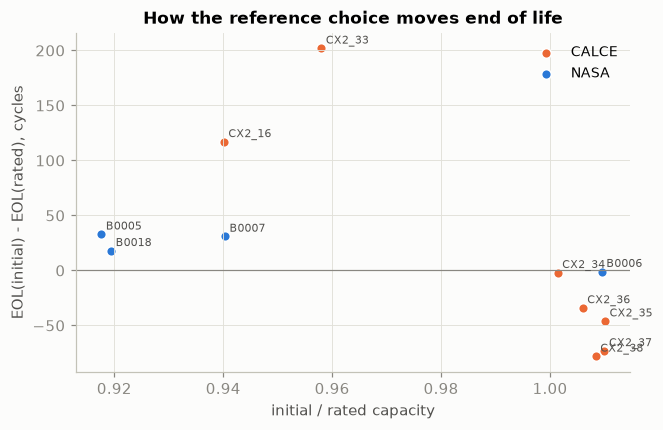

,cell,dataset,initial_over_rated,eol_rated,eol_initial,eol_shift_cycles
0,B0005,NASA,0.9176,74,107,33
1,B0006,NASA,1.0095,63,62,-1
2,B0007,NASA,0.9403,94,125,31
3,B0018,NASA,0.9194,60,78,18
4,CX2_16,CALCE,0.9401,1000,1117,117
5,CX2_33,CALCE,0.9580,621,823,202
6,CX2_34,CALCE,1.0014,661,659,-2
7,CX2_35,CALCE,1.0101,836,790,-46
8,CX2_36,CALCE,1.0060,687,653,-34
9,CX2_37,CALCE,1.0100,760,687,-73


In [5]:
conv = summary[["cell", "dataset", "initial_over_rated", "eol_rated", "eol_initial"]].copy()
conv["eol_shift_cycles"] = conv["eol_initial"] - conv["eol_rated"]
fig, ax = plt.subplots(figsize=(6.5, 4))
for ds, g in conv.groupby("dataset"):
    ax.scatter(g["initial_over_rated"], g["eol_shift_cycles"], s=40, label=ds,
               color="#2a78d6" if ds == "NASA" else "#eb6834", edgecolor="white")
    for _, r in g.iterrows():
        ax.annotate(r["cell"], (r["initial_over_rated"], r["eol_shift_cycles"]),
                    fontsize=7, xytext=(3, 3), textcoords="offset points", color=INK_2)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set(xlabel="initial / rated capacity", ylabel="EOL(initial) - EOL(rated), cycles",
       title="How the reference choice moves end of life"); ax.legend()
savefig(fig, "02_eol_conventions"); plt.show(); conv

## 4. Capacity regeneration and the RQ1 subgroups

A regeneration event is a rise of more than 1% of rated capacity between consecutive cycles. The subgroup split is fixed here, before any model is run: a median split of events per 100 cycles within each dataset.

In [6]:
regimes = regeneration_regimes(summary)
regimes.to_csv(config.PROCESSED_DIR / "regimes.csv", index=False)
regimes.sort_values(["dataset", "regen_per_100_cycles"])

,cell,dataset,regen_per_100_cycles,regime,dataset_median
5,CX2_37,CALCE,1.256,low,2.8700
2,CX2_34,CALCE,2.490,low,2.8700
3,CX2_35,CALCE,2.494,low,2.8700
6,CX2_38,CALCE,2.870,low,2.8700
4,CX2_36,CALCE,4.080,high,2.8700
1,CX2_33,CALCE,4.088,high,2.8700
0,CX2_16,CALCE,8.321,high,2.8700
7,B0005,NASA,4.167,low,5.3575
9,B0007,NASA,4.167,low,5.3575
8,B0006,NASA,6.548,high,5.3575


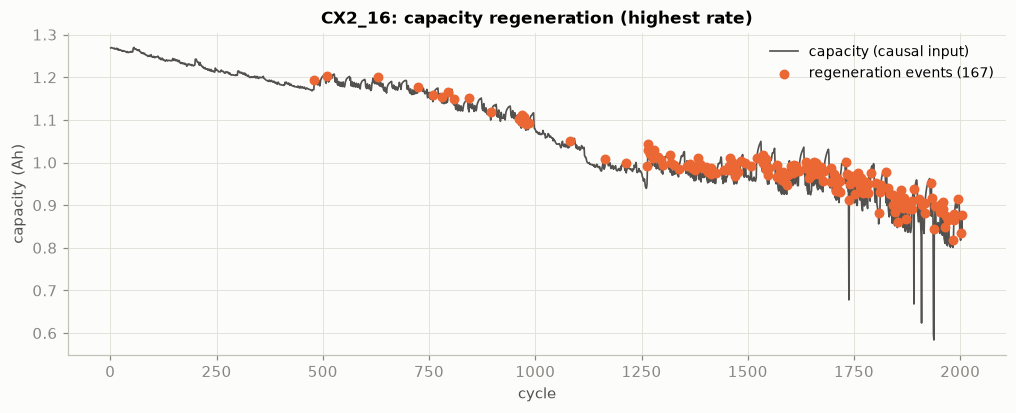

In [7]:
example = max(cells.values(), key=lambda c: c.info["regen_per_100_cycles"])
df = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{example.name}.parquet")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(df["cycle"], df["capacity_input"], color=INK_2, lw=1.1, label="capacity (causal input)")
ev = df[df["is_regeneration"]]
ax.scatter(ev["cycle"], ev["capacity_input"], color="#eb6834", s=30, zorder=3,
           label=f"regeneration events ({len(ev)})")
ax.set(title=f"{example.name}: capacity regeneration (highest rate)", xlabel="cycle", ylabel="capacity (Ah)")
ax.legend(); savefig(fig, "02_regeneration_example"); plt.show()

## 5. Degradation rate over life

Fade per cycle, smoothed over 15 cycles and expressed as a share of rated capacity. A rate that accelerates late in life (a knee) is what a straight-line extrapolation will miss.

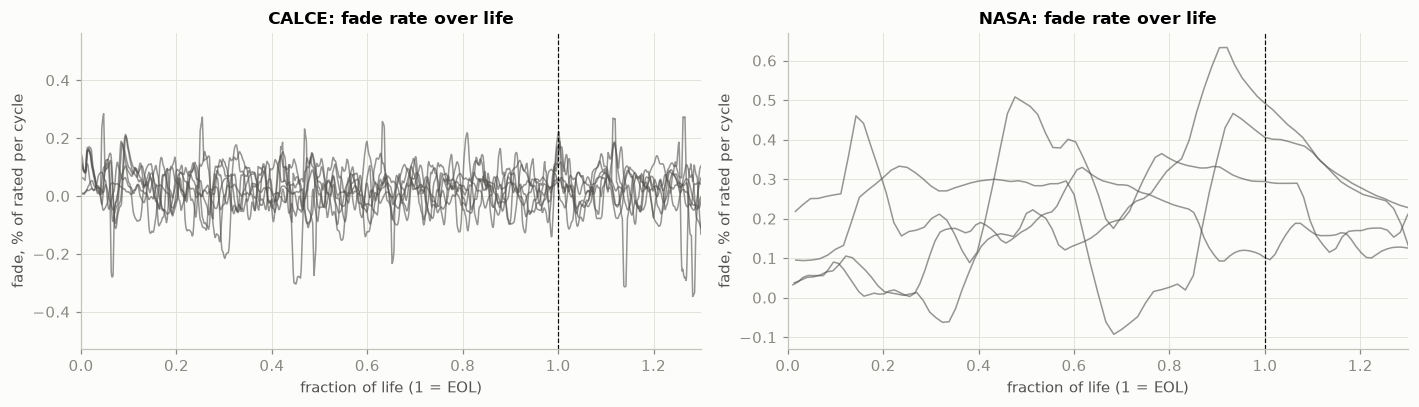

In [8]:
fig, axes = plt.subplots(1, len(cells_by_dataset(cells)), figsize=(13, 3.8), squeeze=False)
for ax, ds in zip(axes[0], cells_by_dataset(cells)):
    for c in (c for c in cells.values() if c.dataset == ds):
        rate = -np.gradient(pd.Series(c.label).rolling(15, center=True, min_periods=1).mean())
        life = np.arange(1, c.n_cycles + 1) / (c.eol[REF] or c.n_cycles)
        ax.plot(life, 100 * rate / c.references["rated"], color=INK_2, lw=1, alpha=0.6)
    ax.axvline(1.0, color=INK, lw=0.8, ls="--")
    ax.set(title=f"{ds}: fade rate over life", xlabel="fraction of life (1 = EOL)",
           ylabel="fade, % of rated per cycle", xlim=(0, 1.3))
fig.tight_layout(); savefig(fig, "02_fade_rate"); plt.show()

## 6. Where the end-of-life region sits relative to the training data

For each leave-one-cell-out fold: the lowest capacity the test cell reaches before its true EOL, against the lowest target value in the training windows. Under full-range training the training data usually extend below the threshold. Under the range-restricted arm, the end-of-life region is outside the training range by construction.

In [9]:
rows = []
for fold in loco_folds(cells, REF):
    w = config.WINDOWS[fold.dataset]
    test = cells[fold.test]; train = [cells[n] for n in fold.train]
    full = build_training_set(train, w.input_len, w.horizon, reference=REF)
    restricted = build_training_set(train, w.input_len, w.horizon, reference=REF,
                                    range_restrict_soh=config.RANGE_RESTRICT_SOH)
    eol = test.eol[REF]
    rows.append({"dataset": fold.dataset, "test_cell": fold.test,
        "threshold_Ah": test.thresholds[REF],
        "test_min_before_eol_Ah": float(test.capacity[:eol].min()),
        "train_target_min_full_Ah": float(full.Y_all.min()),
        "train_target_min_restricted_Ah": float(restricted.Y_all.min()),
        "windows_full": full.n_windows, "windows_restricted": restricted.n_windows})
coverage = pd.DataFrame(rows)
coverage["below_range_full"] = coverage["test_min_before_eol_Ah"] < coverage["train_target_min_full_Ah"]
coverage["below_range_restricted"] = coverage["test_min_before_eol_Ah"] < coverage["train_target_min_restricted_Ah"]
save_table(coverage, "eda_training_range")
print(f"folds below training range: full {coverage['below_range_full'].sum()}/{len(coverage)}, restricted {coverage['below_range_restricted'].sum()}/{len(coverage)}")
coverage

folds below training range: full 0/11, restricted 11/11


,dataset,test_cell,threshold_Ah,test_min_before_eol_Ah,train_target_min_full_Ah,train_target_min_restricted_Ah,windows_full,windows_restricted,below_range_full,below_range_restricted
0,CALCE,CX2_16,1.08,1.075700,0.191416,1.147512,10027,2550,False,True
1,CALCE,CX2_33,1.08,1.077158,0.191416,1.147512,10346,2868,False,True
2,CALCE,CX2_34,1.08,1.052013,0.191416,1.147512,10307,2813,False,True
3,CALCE,CX2_35,1.08,1.076435,0.191416,1.147596,10230,2697,False,True
4,CALCE,CX2_36,1.08,1.071518,0.191416,1.147512,10073,2947,False,True
5,CALCE,CX2_37,1.08,1.064583,0.191416,1.147512,10760,2777,False,True
6,CALCE,CX2_38,1.08,1.069759,0.541421,1.147512,10083,2836,False,True
7,NASA,B0005,1.60,1.601514,1.153818,1.702408,399,77,False,True
8,NASA,B0006,1.60,1.598971,1.287453,1.700311,399,83,False,True
9,NASA,B0007,1.60,1.590651,1.153818,1.700311,399,71,False,True


## 7. Window budget

A window needs L + H cycles, and a forecast origin at fraction f of life needs f x EOL >= L observed cycles. Short NASA lives constrain L hard; CALCE allows much longer windows.

In [10]:
budget_rows = []
for ds, names in cells_by_dataset(cells).items():
    for L in config.RQ3_INPUT_LENS[ds]:
        for H in config.RQ3_HORIZONS[ds]:
            n_windows = [len(make_windows(cells[n].capacity, L, H)[0]) for n in names]
            testable = [n for n in names if cells[n].reaches_eol(REF)]
            n_orig = sum(len(forecast_origins(cells[n], L, REF)) for n in testable)
            budget_rows.append({"dataset": ds, "L": L, "H": H,
                "min_windows_per_cell": min(n_windows), "total_windows": sum(n_windows),
                "origin_coverage": n_orig / max(1, len(testable) * len(config.ORIGIN_FRACS)),
                "is_default": (L, H) == (config.WINDOWS[ds].input_len, config.WINDOWS[ds].horizon)})
budget = pd.DataFrame(budget_rows)
save_table(budget, "eda_window_budget")
budget

,dataset,L,H,min_windows_per_cell,total_windows,origin_coverage,is_default
0,CALCE,16,8,1251,12251,1.000000,False
1,CALCE,16,16,1243,12195,1.000000,False
2,CALCE,16,32,1227,12083,1.000000,False
3,CALCE,32,8,1235,12139,1.000000,False
4,CALCE,32,16,1227,12083,1.000000,False
5,CALCE,32,32,1211,11971,1.000000,False
6,CALCE,48,8,1219,12027,1.000000,False
7,CALCE,48,16,1211,11971,1.000000,True
8,CALCE,48,32,1195,11859,1.000000,False
9,CALCE,64,8,1203,11915,1.000000,False


## 8. Design consequences

In [11]:
for ds, g in summary.groupby("dataset"):
    spread = g["initial_Ah"].max() - g["initial_Ah"].min()
    print(f"{ds}: initial capacity spread {spread:.3f} Ah ({100*spread/g['rated_Ah'].iloc[0]:.1f}% of rated)")
    print(f"{ds}: regeneration {g['regen_per_100_cycles'].min():.2f}-{g['regen_per_100_cycles'].max():.2f} events/100 cycles")
defaults = budget[budget["is_default"]]
for _, r in defaults.iterrows():
    print(f"{r['dataset']}: default L={r['L']}, H={r['H']} serves {r['origin_coverage']:.0%} of origins")
print(f"range-restricted arm: {coverage['below_range_restricted'].sum()}/{len(coverage)} folds below range")
print("next: 03_feature_engineering.ipynb")

CALCE: initial capacity spread 0.095 Ah (7.0% of rated)
CALCE: regeneration 1.26-8.32 events/100 cycles
NASA: initial capacity spread 0.184 Ah (9.2% of rated)
NASA: regeneration 4.17-6.82 events/100 cycles
CALCE: default L=48, H=16 serves 100% of origins
NASA: default L=16, H=8 serves 92% of origins
range-restricted arm: 11/11 folds below range
next: 03_feature_engineering.ipynb


## 9. Data caveats and anomalies

The checks above establish the study design. This section goes one level deeper into the raw files
and flags three properties that the standard overview does not surface, each with a concrete
consequence for modelling or reporting.

### 9.1 NASA `Time` field is identical across B0005, B0006 and B0007

`discharge_time_s` (derived from the `.mat` file's `Time` array) is **byte-identical, cycle for
cycle, across B0005, B0006 and B0007** — confirmed directly from the raw `.mat` structs, not a
caching artefact. Voltage and capacity differ correctly between the three cells; only the timing
grid is shared. This points to how this copy of the NASA PCoE set was assembled (a shared sampling
clock recorded once and attached to all three logs), not a corruption in this repository's loader.

In [12]:
import scipy.io as sio

time_cols = {}
for name in ("B0005", "B0006", "B0007", "B0018"):
    df = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{name}.parquet")
    time_cols[name] = df["discharge_time_s"].to_numpy()

pairs = [("B0005", "B0006"), ("B0005", "B0007"), ("B0006", "B0007"), ("B0005", "B0018")]
rows = [{"pair": f"{a} vs {b}",
         "n_a": len(time_cols[a]), "n_b": len(time_cols[b]),
         "identical_on_overlap": bool(np.array_equal(
             time_cols[a][:min(len(time_cols[a]), len(time_cols[b]))],
             time_cols[b][:min(len(time_cols[a]), len(time_cols[b]))]))}
        for a, b in pairs]
time_dup = pd.DataFrame(rows)
save_table(time_dup, "eda_nasa_time_duplication")
time_dup

,pair,n_a,n_b,identical_on_overlap
0,B0005 vs B0006,168,168,True
1,B0005 vs B0007,168,168,True
2,B0006 vs B0007,168,168,True
3,B0005 vs B0018,168,132,False


**Consequence:** harmless for the current study. `battery_rul/features.py` builds every model
input from the causal capacity series only (`cap_*`, lags, rolling stats) — `discharge_time_s` is
stored in the processed parquet files but never read as a feature. It only becomes a hazard if a
future extension (RQ3's explainability work, or a teammate's exported-sample pipeline) adds
discharge duration as a predictor without knowing three of the four NASA cells share one timing
array: that feature would then carry zero cell-specific information for 3/4 of the dataset,
silently inflating any model that leans on it as if it were informative.

### 9.2 CX2_16 is an outlier within its own CALCE family

CX2_16 differs from its six CALCE siblings on every axis that matters for degradation, not just one:
substantially slower fade, the longest life, the highest regeneration rate, *and* a markedly weaker
capacity/internal-resistance relationship. One anomalous property could be sampling noise; this
combination suggests a different degradation regime, not just a different point on the same curve.

In [13]:
calce_cells = [c for c in cells.values() if c.dataset == "CALCE"]
rows = []
for c in calce_cells:
    df = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{c.name}.parquet")
    corr_r = df["capacity_input"].corr(df["internal_resistance_ohm"])
    rows.append({
        "cell": c.name,
        "n_cycles": c.n_cycles,
        "eol_rated": c.eol["rated"],
        "fade_rate_mAh_per_cycle": c.info["fade_rate_mAh_per_cycle"],
        "regen_per_100_cycles": c.info["regen_per_100_cycles"],
        "corr_capacity_vs_resistance": round(corr_r, 3),
    })
outlier_profile = pd.DataFrame(rows).sort_values("fade_rate_mAh_per_cycle")
save_table(outlier_profile, "eda_calce_outlier_profile")
outlier_profile

,cell,n_cycles,eol_rated,fade_rate_mAh_per_cycle,regen_per_100_cycles,corr_capacity_vs_resistance
0,CX2_16,2007,1000,0.1925,8.321,-0.297
3,CX2_35,1804,836,0.3406,2.494,-0.903
1,CX2_33,1688,621,0.3435,4.088,-0.909
5,CX2_37,1274,760,0.3754,1.256,-0.784
6,CX2_38,1951,741,0.3881,2.870,-0.931
4,CX2_36,1961,687,0.4076,4.080,-0.917
2,CX2_34,1727,661,0.4127,2.490,-0.875


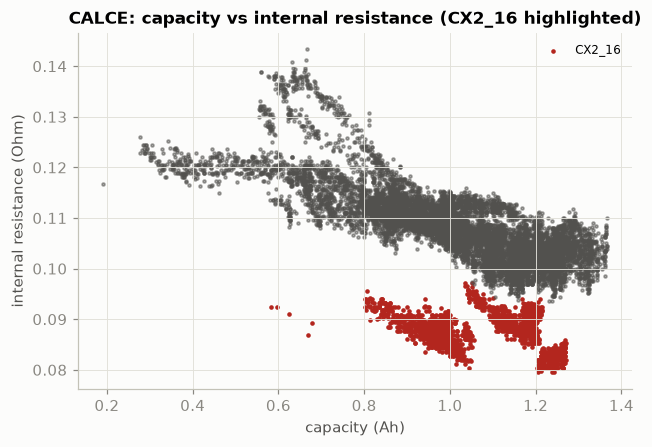

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for c in calce_cells:
    df = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{c.name}.parquet")
    color = "#b3261e" if c.name == "CX2_16" else INK_2
    lw = 1.8 if c.name == "CX2_16" else 1.0
    alpha = 1.0 if c.name == "CX2_16" else 0.5
    ax.scatter(df["capacity_input"], df["internal_resistance_ohm"], s=4, color=color, alpha=alpha,
               label=c.name if c.name == "CX2_16" else None)
ax.set(xlabel="capacity (Ah)", ylabel="internal resistance (Ohm)",
       title="CALCE: capacity vs internal resistance (CX2_16 highlighted)")
ax.legend(fontsize=8)
savefig(fig, "02_cx2_16_outlier"); plt.show()

**Consequence:** under leave-one-cell-out, whichever fold holds out CX2_16 as the *test* cell is
the one most likely to produce the largest RUL error for every model family, linear or tree — the
model trains on six faster-fading, more resistance-coupled cells and is asked to forecast a
slower-fading, decoupled one. Conversely, when CX2_16 is in the *training* set, it pulls the pooled
CALCE training distribution toward "slow fade, high regeneration" in a way the other six do not
support, which can bias every other fold's forecast origin at 75% of life (the region CX2_16's long
tail disproportionately populates). RQ1/RQ2 results should report CX2_16's fold separately from the
other six CALCE folds, or include a with/without-CX2_16 sensitivity row, rather than averaging it
into one CALCE number.

### 9.3 Sample size: regeneration regime split is thin by construction

The whole study runs on 11 cells (33 test units: 11 cells x 3 forecast origins). The regeneration
"high/low" split used for hypothesis H1b is a *median* split within each dataset, which — with only
7 CALCE and 4 NASA cells — cannot produce anything but small, slightly unbalanced groups.

In [15]:
regime_sizes = regimes.groupby(["dataset", "regime"]).size().rename("n_cells").reset_index()
regime_sizes["n_test_units"] = regime_sizes["n_cells"] * len(config.ORIGIN_FRACS)
save_table(regime_sizes, "eda_regime_group_sizes")
regime_sizes

,dataset,regime,n_cells,n_test_units
0,CALCE,high,3,9
1,CALCE,low,4,12
2,NASA,high,2,6
3,NASA,low,2,6


**Consequence:** the smallest subgroup (NASA, either regime) is 2 cells = 6 test units. Any
H1b verdict ("not detected") on a 2-vs-2 or 3-vs-4 cell split should be read as *underpowered*, not
as evidence of no effect — consistent with the limitation the project README already states in
general terms, but worth stating numerically here, at the point where the split is constructed,
rather than only in the final report's limitations section.

In [16]:
print("Data caveats summary:")
print(f"  - NASA Time duplication: {int(time_dup['identical_on_overlap'].sum())}/{len(time_dup)} "
      f"checked pairs share an identical timing array (not used as a model feature)")
print(f"  - CX2_16 vs CALCE siblings: fade rate "
      f"{outlier_profile.loc[outlier_profile['cell'] == 'CX2_16', 'fade_rate_mAh_per_cycle'].iloc[0]:.3f} "
      f"mAh/cycle vs {outlier_profile.loc[outlier_profile['cell'] != 'CX2_16', 'fade_rate_mAh_per_cycle'].min():.3f}"
      f"-{outlier_profile.loc[outlier_profile['cell'] != 'CX2_16', 'fade_rate_mAh_per_cycle'].max():.3f} for the other six; "
      f"capacity/resistance correlation {outlier_profile.loc[outlier_profile['cell'] == 'CX2_16', 'corr_capacity_vs_resistance'].iloc[0]:.2f} "
      f"vs {outlier_profile.loc[outlier_profile['cell'] != 'CX2_16', 'corr_capacity_vs_resistance'].min():.2f}"
      f"-{outlier_profile.loc[outlier_profile['cell'] != 'CX2_16', 'corr_capacity_vs_resistance'].max():.2f} for the other six "
      f"-> report CX2_16's fold separately in RQ1/RQ2")
print(f"  - smallest regeneration-regime subgroup: {int(regime_sizes['n_cells'].min())} cells "
      f"({int(regime_sizes['n_test_units'].min())} test units) -> treat H1b verdicts as low-powered")

Data caveats summary:
  - NASA Time duplication: 3/4 checked pairs share an identical timing array (not used as a model feature)
  - CX2_16 vs CALCE siblings: fade rate 0.193 mAh/cycle vs 0.341-0.413 for the other six; capacity/resistance correlation -0.30 vs -0.93--0.78 for the other six -> report CX2_16's fold separately in RQ1/RQ2
  - smallest regeneration-regime subgroup: 2 cells (6 test units) -> treat H1b verdicts as low-powered
